In [7]:
# Import all thhe modules

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, auc
import warnings
warnings.filterwarnings('ignore')

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, precision_score, recall_score


In [9]:
df = pd.read_csv(r"D:\Sem_4\Supervised Machine Learning lab (SMLL)\7\iphone_purchase_records.csv")

In [10]:
df.head()

,Gender,Age,Salary,Purchase Iphone
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


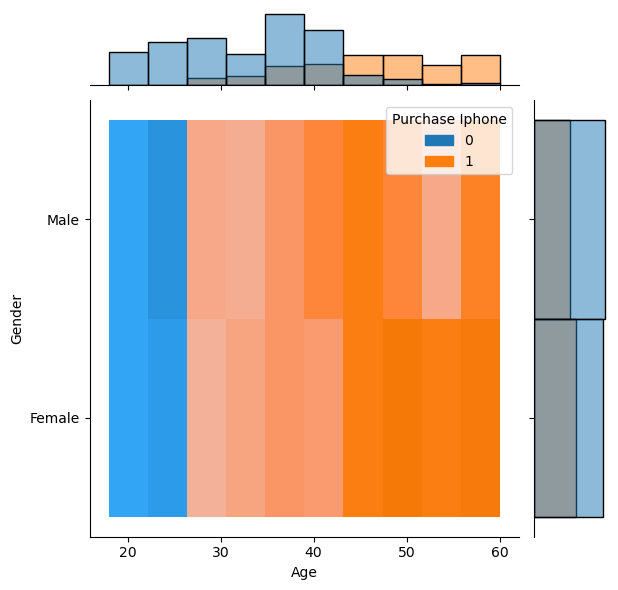

In [11]:
sns.jointplot(x='Age', y='Gender', data=df, hue='Purchase Iphone', kind='hist')

In [12]:
# Convert Gender to number
Label_encoder = LabelEncoder()
df['Gender'] = Label_encoder.fit_transform(df['Gender']) # MALE -> 0, FEMALE-> 1

In [13]:
df['Purchase Iphone'].value_counts()

Purchase Iphone
0    257
1    143
Name: count, dtype: int64

In [14]:
X = df.drop('Purchase Iphone', axis=1)
y = df['Purchase Iphone']

# Step 3 : Split data into train and test

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [17]:
print(X_train.shape)
print(X_test.shape)

(320, 3)
(80, 3)


In [18]:
print(y_train.shape)
print(y_test.shape)

(320,)
(80,)


# Step 4 : Fit into Decision Tree Classifier

In [19]:
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

In [20]:
y_pred = classifier.predict(X_test)

In [21]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc}")
print("Confusion Matrix :\n")
print(confusion_matrix(y_test, y_pred))
print("Classification Report :\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9375
Confusion Matrix :

[[50  2]
 [ 3 25]]
Classification Report :

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        52
           1       0.93      0.89      0.91        28

    accuracy                           0.94        80
   macro avg       0.93      0.93      0.93        80
weighted avg       0.94      0.94      0.94        80



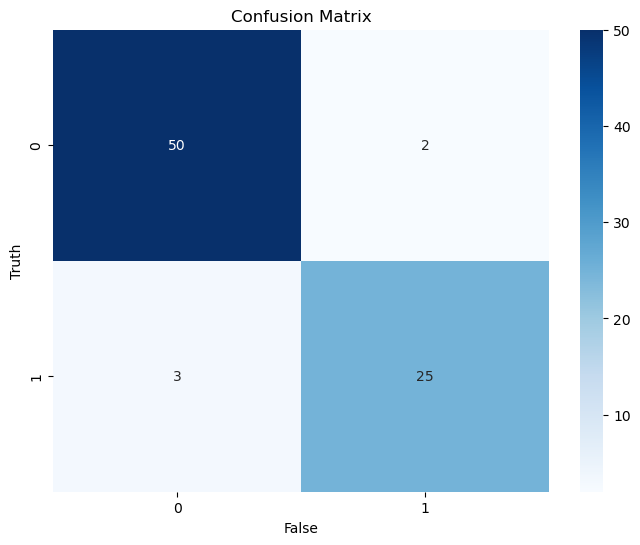

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('False')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
plt.show()


In [23]:
# This gives us probabilities that each test sample belongs to class 1 (Purchase)
y_pred_proba = classifier.predict_proba(X_test)[:, 1]

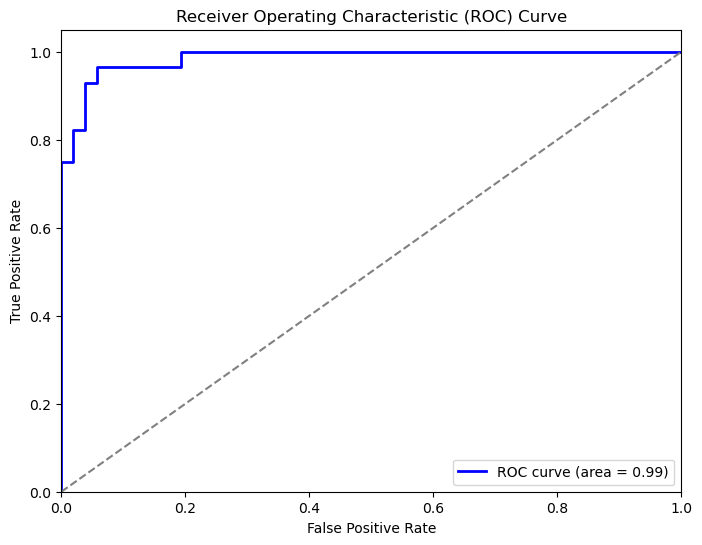

In [24]:
# ROC - AUC curve
fpr,tpr,_ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [25]:
print("Roc_Auc: ", roc_auc_score(y_test, y_pred_proba))


Roc_Auc:  0.9855769230769231
